# CartPole-v1 - Q-Learning vs SARSA
## Projekt 3 (6 i 8 punktów) - Ciągła przestrzeń obserwacji

Środowisko: **CartPole-v1** (Gymnasium) - ciągła przestrzeń obserwacji $\mathbb{R}^4$.  
Algorytmy: **Q-Learning** (off-policy) oraz **SARSA** (on-policy) z dyskretyzacją przestrzeni stanów.

### Zawartość notebooka
1. **Setup** - środowisko, dyskretyzacja, funkcje pomocnicze
2. **Algorytmy** - implementacja Q-Learning i SARSA
3. **Porównanie γ** - trzy współczynniki dyskontowe: 0.7, 0.9, 0.99
4. **Optymalizacja hiperparametrów** - grid search, kryterium: pierwsze 1000 epizodów
5. **Finalne porównanie** - oba algorytmy z najlepszymi hiperparametrami

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import itertools
import time

# ── Środowisko ─────────────────────────────────────────────────────────────
ENV_NAME  = 'CartPole-v1'
SEED      = 42
MAX_STEPS = 500
N_ACTIONS = 2

# ── Dyskretyzacja przestrzeni obserwacji ───────────────────────────────────
# Liczba koszyków dla każdego wymiaru:
# [pozycja wózka, prędkość wózka, kąt drążka, prędkość kątowa drążka]
BINS = (8, 10, 16, 16)

# ── Parametry eksperymentów ────────────────────────────────────────────────
GAMMAS_TO_COMPARE     = [0.7, 0.9, 0.99]  # sekcja porównania gamma
N_EPISODES_COMPARE    = 10_000            # epizody per run w sekcji gamma
N_EPISODES_GRIDSEARCH = 1_000            # kryterium: pierwsze 1000 epizodów
N_EPISODES_FINAL      = 20_000           # finalne porównanie algorytmów

# ── Ewaluacja i wykresy ────────────────────────────────────────────────────
EVAL_WINDOW       = 200   # okno rolling average na wykresach
N_EVAL            = 300   # liczba epizodów ewaluacji greedy
SUCCESS_STRICT    = 475   # próg sukcesu surowy
SUCCESS_PRACTICAL = 200   # próg sukcesu praktyczny

print(f'gymnasium {gym.__version__}  |  numpy {np.__version__}')

gymnasium 1.2.3  |  numpy 2.4.2


In [2]:
# ── Informacje o środowisku ────────────────────────────────────────────────
_env = gym.make(ENV_NAME)
print(f'Observation space: {_env.observation_space}')
print(f'  low:  {_env.observation_space.low}')
print(f'  high: {_env.observation_space.high}')
print(f'Action space: {_env.action_space}')
_env.close()

# ── Krawędzie koszyków (bin edges) ────────────────────────────────────────
# Zakresy dobrane na podstawie typowych wartości w CartPole
X_BINS    = np.linspace(-2.4,    2.4,    BINS[0] - 1, dtype=np.float32)
XDOT_BINS = np.linspace(-2.5,    2.5,    BINS[1] - 1, dtype=np.float32)
TH_BINS   = np.linspace(-0.2095, 0.2095, BINS[2] - 1, dtype=np.float32)
TDOT_BINS = np.linspace(-2.8,    2.8,    BINS[3] - 1, dtype=np.float32)

def discretize(state):
    x, xd, th, thd = np.asarray(state, dtype=np.float32)
    return (
        int(np.clip(np.digitize(x,   X_BINS),    0, BINS[0] - 1)),
        int(np.clip(np.digitize(xd,  XDOT_BINS), 0, BINS[1] - 1)),
        int(np.clip(np.digitize(th,  TH_BINS),   0, BINS[2] - 1)),
        int(np.clip(np.digitize(thd, TDOT_BINS), 0, BINS[3] - 1)),
    )

print(f'\nRozmiar Q-table: {(*BINS, N_ACTIONS)}')
print(f'Liczba parametrów: {np.prod((*BINS, N_ACTIONS)):,}')
print(f'Dyskretyzacja [0,0,0,0] -> {discretize([0, 0, 0, 0])}')

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
  low:  [-4.8               -inf -0.41887903        -inf]
  high: [4.8               inf 0.41887903        inf]
Action space: Discrete(2)

Rozmiar Q-table: (8, 10, 16, 16, 2)
Liczba parametrów: 40,960
Dyskretyzacja [0,0,0,0] -> (4, 5, 8, 8)


In [3]:
# ── Funkcje pomocnicze ────────────────────────────────────────────────────

def new_q_table():
    return np.zeros((*BINS, N_ACTIONS), dtype=np.float32)

def greedy_action(Q, state_idx, rng):
    vals = Q[state_idx]
    best = np.flatnonzero(vals == vals.max())
    return int(rng.choice(best))

def eps_linear(ep, total, eps_start=1.0, eps_min=0.02):
    """Liniowy harmonogram zanikania epsilon."""
    return eps_start + min(1.0, ep / float(total)) * (eps_min - eps_start)

def rolling_avg(arr, window):
    """Rolling average - zwraca (x_values, smoothed_values)."""
    n = len(arr)
    if n < window:
        return np.arange(1, n + 1), np.array(arr, dtype=float)
    s = np.convolve(arr, np.ones(window) / window, mode='valid')
    x = np.arange(window, n + 1)
    return x, s

def evaluate_policy(Q, gamma, n_eval=N_EVAL):
    """Ewaluacja zachłannej polityki - zwraca słownik metryk."""
    env = gym.make(ENV_NAME)
    rng = np.random.default_rng(SEED + 999_999)
    ep_rewards, ep_discounted = [], []

    for ep in range(n_eval):
        state, _ = env.reset(seed=300_000 + ep)
        idx = discretize(state)
        total, disc, d = 0.0, 0.0, 1.0
        for _ in range(MAX_STEPS):
            a = greedy_action(Q, idx, rng)
            ns, r, term, trunc, _ = env.step(a)
            idx = discretize(ns)
            total += r
            disc  += d * r
            d     *= gamma
            if term or trunc:
                break
        ep_rewards.append(total)
        ep_discounted.append(disc)

    env.close()
    return {
        'mean_reward':       float(np.mean(ep_rewards)),
        'mean_discounted':   float(np.mean(ep_discounted)),
        'success_strict':    float(np.mean([r >= SUCCESS_STRICT    for r in ep_rewards])),
        'success_practical': float(np.mean([r >= SUCCESS_PRACTICAL for r in ep_rewards])),
        'min_reward':        float(np.min(ep_rewards)),
        'max_reward':        float(np.max(ep_rewards)),
    }

def discounted_metric(rewards, gamma):
    """
    Całkowita zdyskontowana nagroda w N epizodach.
    W CartPole reward=1 na krok, więc nagroda epizodu = długość epizodu T.
    Zdyskontowany return epizodu: sum_{t=0}^{T-1} gamma^t = (1 - gamma^T)/(1 - gamma).
    """
    T = np.asarray(rewards, dtype=np.float64)
    if abs(gamma - 1.0) < 1e-9:
        return float(np.sum(T))
    return float(np.sum((1.0 - gamma ** T) / (1.0 - gamma)))

print('Funkcje pomocnicze załadowane.')

Funkcje pomocnicze załadowane.


---
## Sekcja 1 - Implementacja algorytmów

Oba algorytmy używają tej samej dyskretyzacji przestrzeni stanów i liniowego harmonogramu ε-greedy.

**Kluczowa różnica:**

| | Q-Learning | SARSA |
|---|---|---|
| Typ | Off-policy | On-policy |
| Aktualizacja | $Q(s,a) \mathrel{+}= \alpha\bigl[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\bigr]$ | $Q(s,a) \mathrel{+}= \alpha\bigl[r + \gamma Q(s',a') - Q(s,a)\bigr]$ |
| Akcja $a'$ | zawsze najlepsza (greedy) | wybrana przez bieżącą politykę ε-greedy |

In [4]:
# ── Algorytm 1: Q-Learning (off-policy) ───────────────────────────────────

def train_qlearning(episodes, alpha, gamma, eps_min=0.02,
                    seed_offset=0, log_every=0):
    """
    Q-Learning z liniowym harmonogramem epsilon.
    Aktualizacja: Q(s,a) += alpha * [r + gamma * max Q(s',:) - Q(s,a)]
    """
    env = gym.make(ENV_NAME)
    rng = np.random.default_rng(SEED + seed_offset)
    Q   = new_q_table()
    episode_rewards, episode_lengths = [], []
    t0  = time.time()

    for ep in range(1, episodes + 1):
        eps   = eps_linear(ep, episodes, eps_min=eps_min)
        state, _ = env.reset(seed=SEED + seed_offset + ep)
        idx   = discretize(state)
        total = 0.0

        for step in range(MAX_STEPS):
            if rng.random() < eps:
                a = env.action_space.sample()
            else:
                a = greedy_action(Q, idx, rng)

            ns, r, term, trunc, _ = env.step(a)
            nidx = discretize(ns)
            done = term or trunc

            best_next = 0.0 if done else float(Q[nidx].max())
            Q[idx + (a,)] += alpha * (r + gamma * best_next - Q[idx + (a,)])

            idx    = nidx
            total += r
            if done:
                break

        episode_rewards.append(total)
        episode_lengths.append(step + 1)

        if log_every and ep % log_every == 0:
            avg = np.mean(episode_rewards[-log_every:])
            pct = np.mean([x >= SUCCESS_PRACTICAL
                           for x in episode_rewards[-log_every:]]) * 100
            print(f'  Q-L  ep={ep:5d}  eps={eps:.3f}  '
                  f'avg={avg:7.1f}  sukces>={SUCCESS_PRACTICAL}: {pct:4.1f}%')

    env.close()
    elapsed = time.time() - t0
    return (Q,
            np.array(episode_rewards,  dtype=np.float32),
            np.array(episode_lengths,  dtype=np.int32),
            elapsed)

print('train_qlearning zdefiniowany.')

train_qlearning zdefiniowany.


In [5]:
# ── Algorytm 2: SARSA (on-policy) ─────────────────────────────────────────

def train_sarsa(episodes, alpha, gamma, eps_min=0.02,
                seed_offset=0, log_every=0):
    """
    SARSA z liniowym harmonogramem epsilon.
    Aktualizacja: Q(s,a) += alpha * [r + gamma * Q(s',a') - Q(s,a)]
    gdzie a' jest wybrane przez tę samą politykę ε-greedy (on-policy).
    """
    env = gym.make(ENV_NAME)
    rng = np.random.default_rng(SEED + seed_offset)
    Q   = new_q_table()
    episode_rewards, episode_lengths = [], []
    t0  = time.time()

    for ep in range(1, episodes + 1):
        eps      = eps_linear(ep, episodes, eps_min=eps_min)
        state, _ = env.reset(seed=SEED + seed_offset + ep)
        idx      = discretize(state)

        # Wybór pierwszej akcji przed pętlą (SARSA: akcja wybrana z góry)
        if rng.random() < eps:
            a = env.action_space.sample()
        else:
            a = greedy_action(Q, idx, rng)

        total = 0.0

        for step in range(MAX_STEPS):
            ns, r, term, trunc, _ = env.step(a)
            nidx = discretize(ns)
            done = term or trunc

            if done:
                q_next = 0.0
                na     = 0  # wartość zastępcza, nie zostanie użyta
            else:
                # Wybierz następną akcję tą samą polityką ε-greedy
                if rng.random() < eps:
                    na = env.action_space.sample()
                else:
                    na = greedy_action(Q, nidx, rng)
                q_next = float(Q[nidx + (na,)])

            Q[idx + (a,)] += alpha * (r + gamma * q_next - Q[idx + (a,)])

            idx    = nidx
            a      = na     # w następnym kroku wykonamy akcję na
            total += r
            if done:
                break

        episode_rewards.append(total)
        episode_lengths.append(step + 1)

        if log_every and ep % log_every == 0:
            avg = np.mean(episode_rewards[-log_every:])
            pct = np.mean([x >= SUCCESS_PRACTICAL
                           for x in episode_rewards[-log_every:]]) * 100
            print(f'  SARSA ep={ep:5d}  eps={eps:.3f}  '
                  f'avg={avg:7.1f}  sukces>={SUCCESS_PRACTICAL}: {pct:4.1f}%')

    env.close()
    elapsed = time.time() - t0
    return (Q,
            np.array(episode_rewards, dtype=np.float32),
            np.array(episode_lengths, dtype=np.int32),
            elapsed)

print('train_sarsa zdefiniowany.')

train_sarsa zdefiniowany.


---
## Sekcja 2 - Porównanie trzech współczynników dyskontowych

Trenujemy oba algorytmy dla γ ∈ {0.7, 0.9, 0.99} przy stałych pozostałych parametrach  
(α = 0.1, ε_min = 0.02, epizody = 10 000).  
Porównanie pokazuje, jak horyzont czasowy agenta wpływa na szybkość i jakość uczenia.

In [6]:
print('=' * 65)
print('Porównanie współczynników dyskontowych')
print(f'gamma ∈ {GAMMAS_TO_COMPARE}  |  alpha=0.1  |  eps_min=0.02')
print(f'Epizody per run: {N_EPISODES_COMPARE}')
print('=' * 65)

gamma_results = {}  # (algo, gamma) -> rewards array

for gamma in GAMMAS_TO_COMPARE:
    print(f'\n--- gamma = {gamma} ---')

    print('  Trening Q-Learning...')
    _, rew_ql, _, t_ql = train_qlearning(
        N_EPISODES_COMPARE, alpha=0.1, gamma=gamma,
        eps_min=0.02, seed_offset=0
    )
    gamma_results[('Q-Learning', gamma)] = rew_ql
    print(f'  Czas: {t_ql:.1f}s  |  '
          f'avg(ostatnie 500): {np.mean(rew_ql[-500:]):.1f}  |  '
          f'avg(ostatnie 100): {np.mean(rew_ql[-100:]):.1f}')

    print('  Trening SARSA...')
    _, rew_sarsa, _, t_sarsa = train_sarsa(
        N_EPISODES_COMPARE, alpha=0.1, gamma=gamma,
        eps_min=0.02, seed_offset=0
    )
    gamma_results[('SARSA', gamma)] = rew_sarsa
    print(f'  Czas: {t_sarsa:.1f}s  |  '
          f'avg(ostatnie 500): {np.mean(rew_sarsa[-500:]):.1f}  |  '
          f'avg(ostatnie 100): {np.mean(rew_sarsa[-100:]):.1f}')

print('\nPorównanie gamm zakończone.')

Porównanie współczynników dyskontowych
gamma ∈ [0.7, 0.9, 0.99]  |  alpha=0.1  |  eps_min=0.02
Epizody per run: 10000

--- gamma = 0.7 ---
  Trening Q-Learning...
  Czas: 51.9s  |  avg(ostatnie 500): 103.0  |  avg(ostatnie 100): 95.3
  Trening SARSA...
  Czas: 59.1s  |  avg(ostatnie 500): 109.9  |  avg(ostatnie 100): 116.0

--- gamma = 0.9 ---
  Trening Q-Learning...
  Czas: 98.2s  |  avg(ostatnie 500): 148.4  |  avg(ostatnie 100): 146.5
  Trening SARSA...
  Czas: 75.4s  |  avg(ostatnie 500): 175.4  |  avg(ostatnie 100): 166.3

--- gamma = 0.99 ---
  Trening Q-Learning...
  Czas: 142.9s  |  avg(ostatnie 500): 314.7  |  avg(ostatnie 100): 287.8
  Trening SARSA...
  Czas: 135.1s  |  avg(ostatnie 500): 273.5  |  avg(ostatnie 100): 235.5

Porównanie gamm zakończone.


In [7]:
# Tabela podsumowująca wyniki porównania gamm
print(f'\n{"Algorytm":<12} {"gamma":>6}  {"avg(last 500)":>14} {"avg(last 100)":>14} {"max":>8}')
print('-' * 60)
for algo in ['Q-Learning', 'SARSA']:
    for gamma in GAMMAS_TO_COMPARE:
        rew = gamma_results[(algo, gamma)]
        print(f'{algo:<12} {gamma:>6.2f}  '
              f'{np.mean(rew[-500:]):>14.1f} '
              f'{np.mean(rew[-100:]):>14.1f} '
              f'{np.max(rew):>8.0f}')
    print()


Algorytm      gamma   avg(last 500)  avg(last 100)      max
------------------------------------------------------------
Q-Learning     0.70           103.0           95.3      500
Q-Learning     0.90           148.4          146.5      500
Q-Learning     0.99           314.7          287.8      500

SARSA          0.70           109.9          116.0      500
SARSA          0.90           175.4          166.3      500
SARSA          0.99           273.5          235.5      500



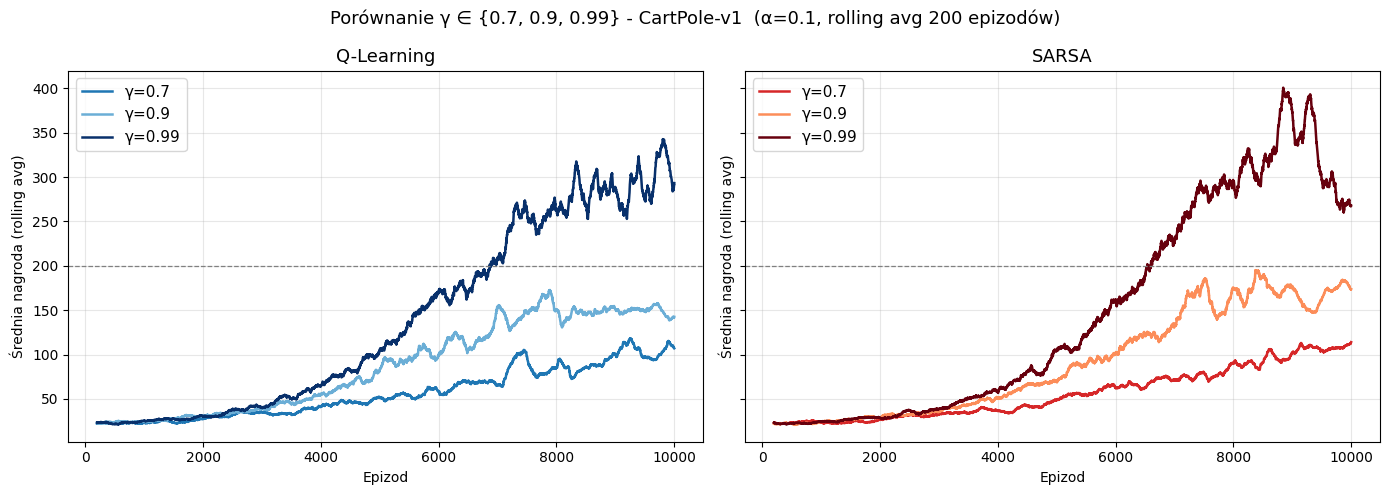

Zapisano: gamma_comparison.png


In [8]:
# Wykres porównania gamm - dwa subploty (jeden per algorytm)
COLORS_QL = {
    0.7:  '#1f77b4',
    0.9:  '#6baed6',
    0.99: '#08306b',
}
COLORS_SARSA = {
    0.7:  '#d62728',
    0.9:  '#fc8d59',
    0.99: '#67000d',
}
COLOR_MAP = {**{('Q-Learning', g): c for g, c in COLORS_QL.items()},
             **{('SARSA',      g): c for g, c in COLORS_SARSA.items()}}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, algo in zip(axes, ['Q-Learning', 'SARSA']):
    for gamma in GAMMAS_TO_COMPARE:
        rew = gamma_results[(algo, gamma)]
        x, s = rolling_avg(rew, EVAL_WINDOW)
        ax.plot(x, s, color=COLOR_MAP[(algo, gamma)],
                label=f'\u03b3={gamma}', linewidth=1.8)
    ax.set_title(algo, fontsize=13)
    ax.set_xlabel('Epizod')
    ax.set_ylabel('Średnia nagroda (rolling avg)')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.axhline(SUCCESS_PRACTICAL, color='gray', linestyle='--',
               linewidth=0.9, label=f'próg {SUCCESS_PRACTICAL}')

gammas_str = ', '.join(str(g) for g in GAMMAS_TO_COMPARE)
plt.suptitle(f'Porównanie \u03b3 \u2208 {{{gammas_str}}} - CartPole-v1  '
             f'(\u03b1=0.1, rolling avg {EVAL_WINDOW} epizodów)',
             fontsize=13)
plt.tight_layout()
plt.savefig('gamma_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Zapisano: gamma_comparison.png')

### Analiza wpływu współczynnika dyskontowego γ

Współczynnik γ kontroluje, jak dalece agent uwzględnia przyszłe nagrody:

- **γ = 0.7** - agent *krótkowzroczny*: nagroda 10 kroków naprzód jest ważona tylko $0.7^{10} \approx 0.028$ raza. Agent koncentruje się na natychmiastowych konsekwencjach, co w CartPole - gdzie cel to utrzymywać drążek *długo* - prowadzi do wolniejszego uczenia i słabszej końcowej polityki.

- **γ = 0.9** - kompromis: nagroda 10 kroków naprzód waży $0.9^{10} \approx 0.35$ raza. Agent widzi perspektywę kilkudziesięciu kroków, co jest wystarczające do nauki podstawowej równowagi.

- **γ = 0.99** - agent *dalekowzroczny*: nagroda 100 kroków naprzód waży $0.99^{100} \approx 0.37$ raza. Agent "rozumie", że każdy krok utrzymania drążka jest cenny w dalekim horyzoncie. W CartPole skutkuje to najlepszą końcową polityką, ale może spowalniać konwergencję na początku treningu przez bardziej rozbudowane propagowanie wartości.

---
## Sekcja 3 - Optymalizacja hiperparametrów

**Kryterium**: całkowita zdyskontowana nagroda w pierwszych 1000 epizodach.  
W CartPole (reward = 1 na krok, długość epizodu = T) zdyskontowany return jednego epizodu:
$$G = \sum_{t=0}^{T-1} \gamma^t = \frac{1 - \gamma^T}{1 - \gamma}$$

**Przeszukiwana siatka**:  
- α (learning rate) ∈ {0.05, 0.1, 0.2}
- γ (discount) ∈ {0.7, 0.9, 0.99}
- ε_min ∈ {0.01, 0.05}

Łącznie: 3 × 3 × 2 = **18 kombinacji** × 2 algorytmy = **36 treningów**.

In [9]:
ALPHA_GRID   = [0.05, 0.1, 0.2]
GAMMA_GRID   = [0.7, 0.9, 0.99]
EPS_MIN_GRID = [0.01, 0.05]

gs_results = {}  # (algo, alpha, gamma, eps_min) -> metric value

combos = list(itertools.product(ALPHA_GRID, GAMMA_GRID, EPS_MIN_GRID))
n_combos = len(combos)
print(f'Grid search: {n_combos} kombinacji × 2 algorytmy = {2 * n_combos} treningów')
print(f'Epizody per run: {N_EPISODES_GRIDSEARCH}')
print()

t_total = time.time()
for i, (alpha, gamma, eps_min) in enumerate(combos):
    _, rew_ql, _, _    = train_qlearning(
        N_EPISODES_GRIDSEARCH, alpha, gamma, eps_min,
        seed_offset=i * 2
    )
    _, rew_sarsa, _, _ = train_sarsa(
        N_EPISODES_GRIDSEARCH, alpha, gamma, eps_min,
        seed_offset=i * 2 + 1
    )

    m_ql    = discounted_metric(rew_ql,    gamma)
    m_sarsa = discounted_metric(rew_sarsa, gamma)
    gs_results[('Q-Learning', alpha, gamma, eps_min)] = m_ql
    gs_results[('SARSA',      alpha, gamma, eps_min)] = m_sarsa

    print(f'[{i+1:2d}/{n_combos}] '
          f'alpha={alpha:.2f}  gamma={gamma:.2f}  eps_min={eps_min:.2f}  |  '
          f'Q-L: {m_ql:8.1f}   SARSA: {m_sarsa:8.1f}')

print(f'\nGrid search zakończony w {time.time() - t_total:.1f}s')

Grid search: 18 kombinacji × 2 algorytmy = 36 treningów
Epizody per run: 1000

[ 1/18] alpha=0.05  gamma=0.70  eps_min=0.01  |  Q-L:   3320.9   SARSA:   3321.0
[ 2/18] alpha=0.05  gamma=0.70  eps_min=0.05  |  Q-L:   3319.8   SARSA:   3320.2
[ 3/18] alpha=0.05  gamma=0.90  eps_min=0.01  |  Q-L:   8666.1   SARSA:   8738.4
[ 4/18] alpha=0.05  gamma=0.90  eps_min=0.05  |  Q-L:   8716.8   SARSA:   8977.3
[ 5/18] alpha=0.05  gamma=0.99  eps_min=0.01  |  Q-L:  21993.1   SARSA:  24622.8
[ 6/18] alpha=0.05  gamma=0.99  eps_min=0.05  |  Q-L:  23340.5   SARSA:  22663.0
[ 7/18] alpha=0.10  gamma=0.70  eps_min=0.01  |  Q-L:   3322.4   SARSA:   3324.2
[ 8/18] alpha=0.10  gamma=0.70  eps_min=0.05  |  Q-L:   3326.4   SARSA:   3322.6
[ 9/18] alpha=0.10  gamma=0.90  eps_min=0.01  |  Q-L:   8791.7   SARSA:   8871.0
[10/18] alpha=0.10  gamma=0.90  eps_min=0.05  |  Q-L:   8933.2   SARSA:   9025.4
[11/18] alpha=0.10  gamma=0.99  eps_min=0.01  |  Q-L:  28433.5   SARSA:  28761.8
[12/18] alpha=0.10  gamma=0.99

In [10]:
# Najlepsze hiperparametry dla każdego algorytmu
best_ql_key    = max((k for k in gs_results if k[0] == 'Q-Learning'),
                     key=lambda k: gs_results[k])
best_sarsa_key = max((k for k in gs_results if k[0] == 'SARSA'),
                     key=lambda k: gs_results[k])

BEST_QL    = {'alpha': best_ql_key[1],    'gamma': best_ql_key[2],    'eps_min': best_ql_key[3]}
BEST_SARSA = {'alpha': best_sarsa_key[1], 'gamma': best_sarsa_key[2], 'eps_min': best_sarsa_key[3]}

print('=== Najlepsze hiperparametry (kryterium: zdyskontowana nagroda, 1000 epizodów) ===')
print()
print(f'Q-Learning: alpha={BEST_QL["alpha"]}  gamma={BEST_QL["gamma"]}  eps_min={BEST_QL["eps_min"]}')
print(f'  Metryka: {gs_results[best_ql_key]:.1f}')
print()
print(f'SARSA:      alpha={BEST_SARSA["alpha"]}  gamma={BEST_SARSA["gamma"]}  eps_min={BEST_SARSA["eps_min"]}')
print(f'  Metryka: {gs_results[best_sarsa_key]:.1f}')

print('\n=== Top 5 Q-Learning ===')
ql_sorted = sorted(
    [(k, v) for k, v in gs_results.items() if k[0] == 'Q-Learning'],
    key=lambda x: -x[1]
)
for k, v in ql_sorted[:5]:
    print(f'  alpha={k[1]:.2f}  gamma={k[2]:.2f}  eps_min={k[3]:.2f}  ->  {v:.1f}')

print('\n=== Top 5 SARSA ===')
sarsa_sorted = sorted(
    [(k, v) for k, v in gs_results.items() if k[0] == 'SARSA'],
    key=lambda x: -x[1]
)
for k, v in sarsa_sorted[:5]:
    print(f'  alpha={k[1]:.2f}  gamma={k[2]:.2f}  eps_min={k[3]:.2f}  ->  {v:.1f}')

=== Najlepsze hiperparametry (kryterium: zdyskontowana nagroda, 1000 epizodów) ===

Q-Learning: alpha=0.2  gamma=0.99  eps_min=0.05
  Metryka: 42724.2

SARSA:      alpha=0.2  gamma=0.99  eps_min=0.05
  Metryka: 41951.8

=== Top 5 Q-Learning ===
  alpha=0.20  gamma=0.99  eps_min=0.05  ->  42724.2
  alpha=0.20  gamma=0.99  eps_min=0.01  ->  41000.8
  alpha=0.10  gamma=0.99  eps_min=0.01  ->  28433.5
  alpha=0.10  gamma=0.99  eps_min=0.05  ->  23349.9
  alpha=0.05  gamma=0.99  eps_min=0.05  ->  23340.5

=== Top 5 SARSA ===
  alpha=0.20  gamma=0.99  eps_min=0.05  ->  41951.8
  alpha=0.20  gamma=0.99  eps_min=0.01  ->  40622.7
  alpha=0.10  gamma=0.99  eps_min=0.01  ->  28761.8
  alpha=0.10  gamma=0.99  eps_min=0.05  ->  26186.7
  alpha=0.05  gamma=0.99  eps_min=0.01  ->  24622.8


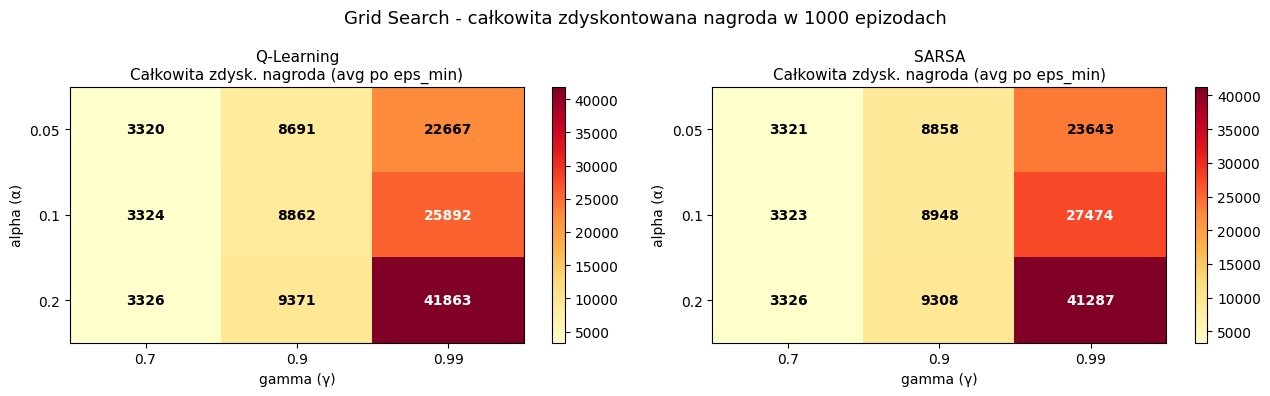

Zapisano: gridsearch_heatmap.png


In [11]:
# Heatmapa wyników grid search (alpha × gamma, uśrednione po eps_min)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, algo in zip(axes, ['Q-Learning', 'SARSA']):
    matrix = np.zeros((len(ALPHA_GRID), len(GAMMA_GRID)))
    for i, alpha in enumerate(ALPHA_GRID):
        for j, gamma in enumerate(GAMMA_GRID):
            vals = [gs_results[(algo, alpha, gamma, em)] for em in EPS_MIN_GRID]
            matrix[i, j] = np.mean(vals)

    im = ax.imshow(matrix, aspect='auto', cmap='YlOrRd')
    ax.set_xticks(range(len(GAMMA_GRID)))
    ax.set_xticklabels([str(g) for g in GAMMA_GRID])
    ax.set_yticks(range(len(ALPHA_GRID)))
    ax.set_yticklabels([str(a) for a in ALPHA_GRID])
    ax.set_xlabel('gamma (\u03b3)')
    ax.set_ylabel('alpha (\u03b1)')
    ax.set_title(f'{algo}\nCałkowita zdysk. nagroda (avg po eps_min)', fontsize=11)
    plt.colorbar(im, ax=ax)

    vmax = matrix.max()
    for i in range(len(ALPHA_GRID)):
        for j in range(len(GAMMA_GRID)):
            col = 'white' if matrix[i, j] > 0.6 * vmax else 'black'
            ax.text(j, i, f'{matrix[i, j]:.0f}',
                    ha='center', va='center', fontsize=10, color=col, fontweight='bold')

plt.suptitle('Grid Search - całkowita zdyskontowana nagroda w 1000 epizodach',
             fontsize=13)
plt.tight_layout()
plt.savefig('gridsearch_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Zapisano: gridsearch_heatmap.png')

---
## Sekcja 4 - Finalne porównanie algorytmów

Trenujemy oba algorytmy z hiperparametrami wybranymi przez grid search przez **20 000 epizodów**.  
Następnie porównujemy krzywe uczenia, finalne metryki i czas treningu.

In [12]:
print('=' * 65)
print('Finalne porównanie: Q-Learning vs SARSA')
print('=' * 65)
print(f'Q-Learning: {BEST_QL}')
print(f'SARSA:      {BEST_SARSA}')
print(f'Epizody: {N_EPISODES_FINAL}')
print()

print('Trening Q-Learning...')
Q_final_ql, rew_final_ql, len_final_ql, t_ql = train_qlearning(
    N_EPISODES_FINAL, log_every=2000, seed_offset=500, **BEST_QL
)
print(f'Zakończono w {t_ql:.1f}s  |  avg(ostatnie 500): {np.mean(rew_final_ql[-500:]):.1f}')

print()
print('Trening SARSA...')
Q_final_sarsa, rew_final_sarsa, len_final_sarsa, t_sarsa = train_sarsa(
    N_EPISODES_FINAL, log_every=2000, seed_offset=600, **BEST_SARSA
)
print(f'Zakończono w {t_sarsa:.1f}s  |  avg(ostatnie 500): {np.mean(rew_final_sarsa[-500:]):.1f}')

Finalne porównanie: Q-Learning vs SARSA
Q-Learning: {'alpha': 0.2, 'gamma': 0.99, 'eps_min': 0.05}
SARSA:      {'alpha': 0.2, 'gamma': 0.99, 'eps_min': 0.05}
Epizody: 20000

Trening Q-Learning...
  Q-L  ep= 2000  eps=0.905  avg=   24.2  sukces>=200:  0.0%
  Q-L  ep= 4000  eps=0.810  avg=   30.1  sukces>=200:  0.0%
  Q-L  ep= 6000  eps=0.715  avg=   40.7  sukces>=200:  0.1%
  Q-L  ep= 8000  eps=0.620  avg=   56.9  sukces>=200:  0.5%
  Q-L  ep=10000  eps=0.525  avg=   79.2  sukces>=200:  2.8%
  Q-L  ep=12000  eps=0.430  avg=  108.0  sukces>=200:  9.6%
  Q-L  ep=14000  eps=0.335  avg=  151.6  sukces>=200: 23.6%
  Q-L  ep=16000  eps=0.240  avg=  206.3  sukces>=200: 44.0%
  Q-L  ep=18000  eps=0.145  avg=  261.3  sukces>=200: 63.8%
  Q-L  ep=20000  eps=0.050  avg=  274.2  sukces>=200: 71.2%
Zakończono w 250.6s  |  avg(ostatnie 500): 284.0

Trening SARSA...
  SARSA ep= 2000  eps=0.905  avg=   23.6  sukces>=200:  0.0%
  SARSA ep= 4000  eps=0.810  avg=   30.6  sukces>=200:  0.0%
  SARSA ep= 600

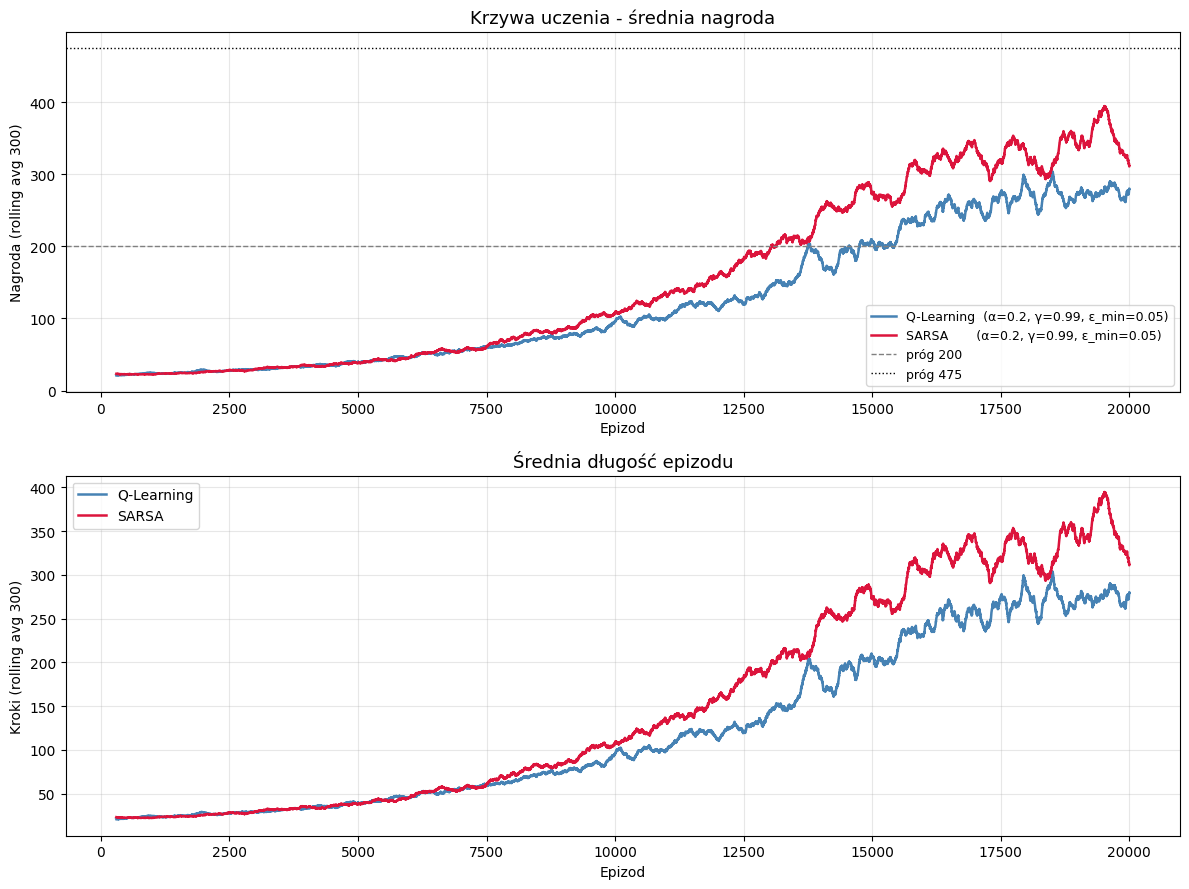

Zapisano: final_comparison.png


In [13]:
# Wykresy finalnego porównania
SMOOTH_FINAL = 300

ql_label    = (f'Q-Learning  '
               f'(\u03b1={BEST_QL["alpha"]}, \u03b3={BEST_QL["gamma"]}, '
               f'\u03b5_min={BEST_QL["eps_min"]})')
sarsa_label = (f'SARSA       '
               f'(\u03b1={BEST_SARSA["alpha"]}, \u03b3={BEST_SARSA["gamma"]}, '
               f'\u03b5_min={BEST_SARSA["eps_min"]})')

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

# Subplot 1: krzywe nagrody
ax = axes[0]
for rew, label, color in [
    (rew_final_ql,    ql_label,    'steelblue'),
    (rew_final_sarsa, sarsa_label, 'crimson'),
]:
    x, s = rolling_avg(rew, SMOOTH_FINAL)
    ax.plot(x, s, color=color, label=label, linewidth=1.8)
ax.axhline(SUCCESS_PRACTICAL, color='gray', linestyle='--',
           linewidth=1.0, label=f'próg {SUCCESS_PRACTICAL}')
ax.axhline(SUCCESS_STRICT,    color='black', linestyle=':',
           linewidth=1.0, label=f'próg {SUCCESS_STRICT}')
ax.set_title('Krzywa uczenia - średnia nagroda', fontsize=13)
ax.set_xlabel('Epizod')
ax.set_ylabel(f'Nagroda (rolling avg {SMOOTH_FINAL})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Subplot 2: długość epizodów
ax = axes[1]
for lengths, label, color in [
    (len_final_ql,    'Q-Learning', 'steelblue'),
    (len_final_sarsa, 'SARSA',      'crimson'),
]:
    x, s = rolling_avg(lengths.astype(float), SMOOTH_FINAL)
    ax.plot(x, s, color=color, label=label, linewidth=1.8)
ax.set_title('Średnia długość epizodu', fontsize=13)
ax.set_xlabel('Epizod')
ax.set_ylabel(f'Kroki (rolling avg {SMOOTH_FINAL})')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Zapisano: final_comparison.png')

In [14]:
# Ewaluacja finalnych modeli (zachłanna polityka, N_EVAL epizodów)
print('Ewaluacja greedy policy...')
eval_ql    = evaluate_policy(Q_final_ql,    BEST_QL['gamma'])
eval_sarsa = evaluate_policy(Q_final_sarsa, BEST_SARSA['gamma'])

print()
print(f'{"": <35} {"Q-Learning":>12} {"SARSA":>12}')
print('-' * 62)
rows = [
    ('Średnia nagroda',              'mean_reward',       '{:12.2f}'),
    ('Śr. nagroda zdyskontowana',    'mean_discounted',   '{:12.4f}'),
    (f'Sukces >= {SUCCESS_STRICT} [%]',  'success_strict',    '{:11.1f}%'),
    (f'Sukces >= {SUCCESS_PRACTICAL} [%]','success_practical', '{:11.1f}%'),
    ('Min nagroda',                  'min_reward',        '{:12.1f}'),
    ('Max nagroda',                  'max_reward',        '{:12.1f}'),
]
for label, key, fmt in rows:
    v_ql    = eval_ql[key]
    v_sarsa = eval_sarsa[key]
    if '%' in fmt:
        v_ql    *= 100
        v_sarsa *= 100
    print(f'{label:<35} {fmt.format(v_ql)} {fmt.format(v_sarsa)}')
print('-' * 62)
print(f'{"Czas treningu [s]":<35} {t_ql:>12.1f} {t_sarsa:>12.1f}')
print(f'{"Liczba epizodów treningu":<35} {N_EPISODES_FINAL:>12,} {N_EPISODES_FINAL:>12,}')

Ewaluacja greedy policy...

                                      Q-Learning        SARSA
--------------------------------------------------------------
Średnia nagroda                           331.79       286.86
Śr. nagroda zdyskontowana                93.6993      92.2776
Sukces >= 475 [%]                          18.0%         4.3%
Sukces >= 200 [%]                          86.7%        81.7%
Min nagroda                                120.0        124.0
Max nagroda                                500.0        500.0
--------------------------------------------------------------
Czas treningu [s]                          250.6        301.5
Liczba epizodów treningu                  20,000       20,000


In [15]:
# Zapis artefaktów
np.save('q_table_qlearning_final.npy',  Q_final_ql)
np.save('q_table_sarsa_final.npy',      Q_final_sarsa)

# Historia treningu dla obu algorytmów (finalne runy)
np.savez(
    'training_history.npz',
    rew_ql            = rew_final_ql,
    rew_sarsa         = rew_final_sarsa,
    len_ql            = len_final_ql,
    len_sarsa         = len_final_sarsa,
    best_ql_params    = np.array([BEST_QL['alpha'],    BEST_QL['gamma'],    BEST_QL['eps_min']]),
    best_sarsa_params = np.array([BEST_SARSA['alpha'], BEST_SARSA['gamma'], BEST_SARSA['eps_min']]),
)

print('Zapisane pliki:')
print(f'  q_table_qlearning_final.npy  (shape: {Q_final_ql.shape})')
print(f'  q_table_sarsa_final.npy      (shape: {Q_final_sarsa.shape})')
print('  training_history.npz')
print()
print('Wykresy:')
print('  gamma_comparison.png')
print('  gridsearch_heatmap.png')
print('  final_comparison.png')

Zapisane pliki:
  q_table_qlearning_final.npy  (shape: (8, 10, 16, 16, 2))
  q_table_sarsa_final.npy      (shape: (8, 10, 16, 16, 2))
  training_history.npz

Wykresy:
  gamma_comparison.png
  gridsearch_heatmap.png
  final_comparison.png
